# Logical H Gate — Fold-Transversal (Rotated Surface Code)

The fold-transversal Hadamard implements the logical $\bar H$ by a transversal
physical Hadamard followed by a **fold** (a qubit permutation):

$$U_H = \Big(\text{90}^\circ\text{ rotation SWAP network}\Big)\;\prod_{j\in D} H_{q_j}.$$

- Apply $H$ to **every data qubit** ($X \leftrightarrow Z$ on each qubit).
- Apply a SWAP network that **rotates the patch 90°**.

For the **rotated** surface code the correct fold is a 90° rotation — *not* the
diagonal reflection used for the unrotated code. The rotated code's only
*ZX-duality* (the permutation that swaps $X$- and $Z$-stabilizers) is the 90°
rotation; its diagonal reflections are CSS automorphisms and do **not** preserve
the stabilizer group on this layout. This matches the handbook's Fig. 24, *"physical
Hadamard gates are first applied to all data qubits; a SWAP permutation then
rotates the patch."*

Logical action: $\bar X \leftrightarrow \bar Z$. The construction is verified by a
stabilizer-tableau check to preserve the stabilizer group and exchange the logical
operators at $d = 3, 5, 7$.

> **Note on S:** the handbook's transversal $\bar S$ (CZ across diagonal mirror
> pairs + $S/S^\dagger$ on the diagonal) needs an *order-2 reflection* ZX-duality,
> which the LightStim rotated layout does not have — so only $\bar H$ is realized
> here. The full $\bar H$ **and** $\bar S$ demonstration lives in
> `logical_H_S_unrotated.ipynb`.

Two sub-experiments verify the action on the logical bases:
- `H_ZtoX`: prepare $|0\rangle_L$ (Z-basis), apply H, measure X-basis → expect +1.
- `H_XtoZ`: prepare $|+\rangle_L$ (X-basis), apply H, measure Z-basis → expect +1.

Both circuits: init → SE → H → SE → readout.  Code: **Rotated** Surface Code, d=3, p=1e-3.

In [1]:
import sys
from pathlib import Path
import io, contextlib

ROOT = Path("../..").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from lightstim.protocols.fold_transversal import build_gate_verification_circuit
from lightstim.qec_code.surface_code.rotated import (
    RotatedSurfaceCode, RotatedSurfaceCodeExtractionBlock,
)
from lightstim.noise.config import NoiseConfig
from lightstim.simulation.decoder_backend import SimulationPipeline, DecoderConfig

In [2]:
d = 3
p = 1e-3
rounds = 1
noise_params = NoiseConfig(p_idle=p, p_1q=p, p_2q=p, p_meas=p, p_reset=p)

## 1. H Gate Circuit

Two sub-experiments verifying the Hadamard action on the logical bases:
- `H_ZtoX`: prepare $|0\rangle_L$ (Z-basis), apply H, measure X-basis → expect +1.
- `H_XtoZ`: prepare $|+\rangle_L$ (X-basis), apply H, measure Z-basis → expect +1.

`fold_transversal_hadamard` applies physical $H$ to all data qubits, then the
90°-rotation SWAP network.

In [3]:
with contextlib.redirect_stdout(io.StringIO()):
    circuit_H_ZtoX = build_gate_verification_circuit(
        d, ["fold_transversal_hadamard"], init_basis="Z", measure_basis="X",
        rounds=rounds, unencode=False, noise_params=noise_params,
        code_patch_class=RotatedSurfaceCode,
        extraction_block_class=RotatedSurfaceCodeExtractionBlock,
    )
    circuit_H_XtoZ = build_gate_verification_circuit(
        d, ["fold_transversal_hadamard"], init_basis="X", measure_basis="Z",
        rounds=rounds, unencode=False, noise_params=noise_params,
        code_patch_class=RotatedSurfaceCode,
        extraction_block_class=RotatedSurfaceCodeExtractionBlock,
    )

print(f"H (Z->X): {circuit_H_ZtoX.num_qubits} qubits, {circuit_H_ZtoX.num_detectors} detectors")
print(f"H (X->Z): {circuit_H_XtoZ.num_qubits} qubits, {circuit_H_XtoZ.num_detectors} detectors")

H (Z->X): 17 qubits, 16 detectors
H (X->Z): 17 qubits, 16 detectors


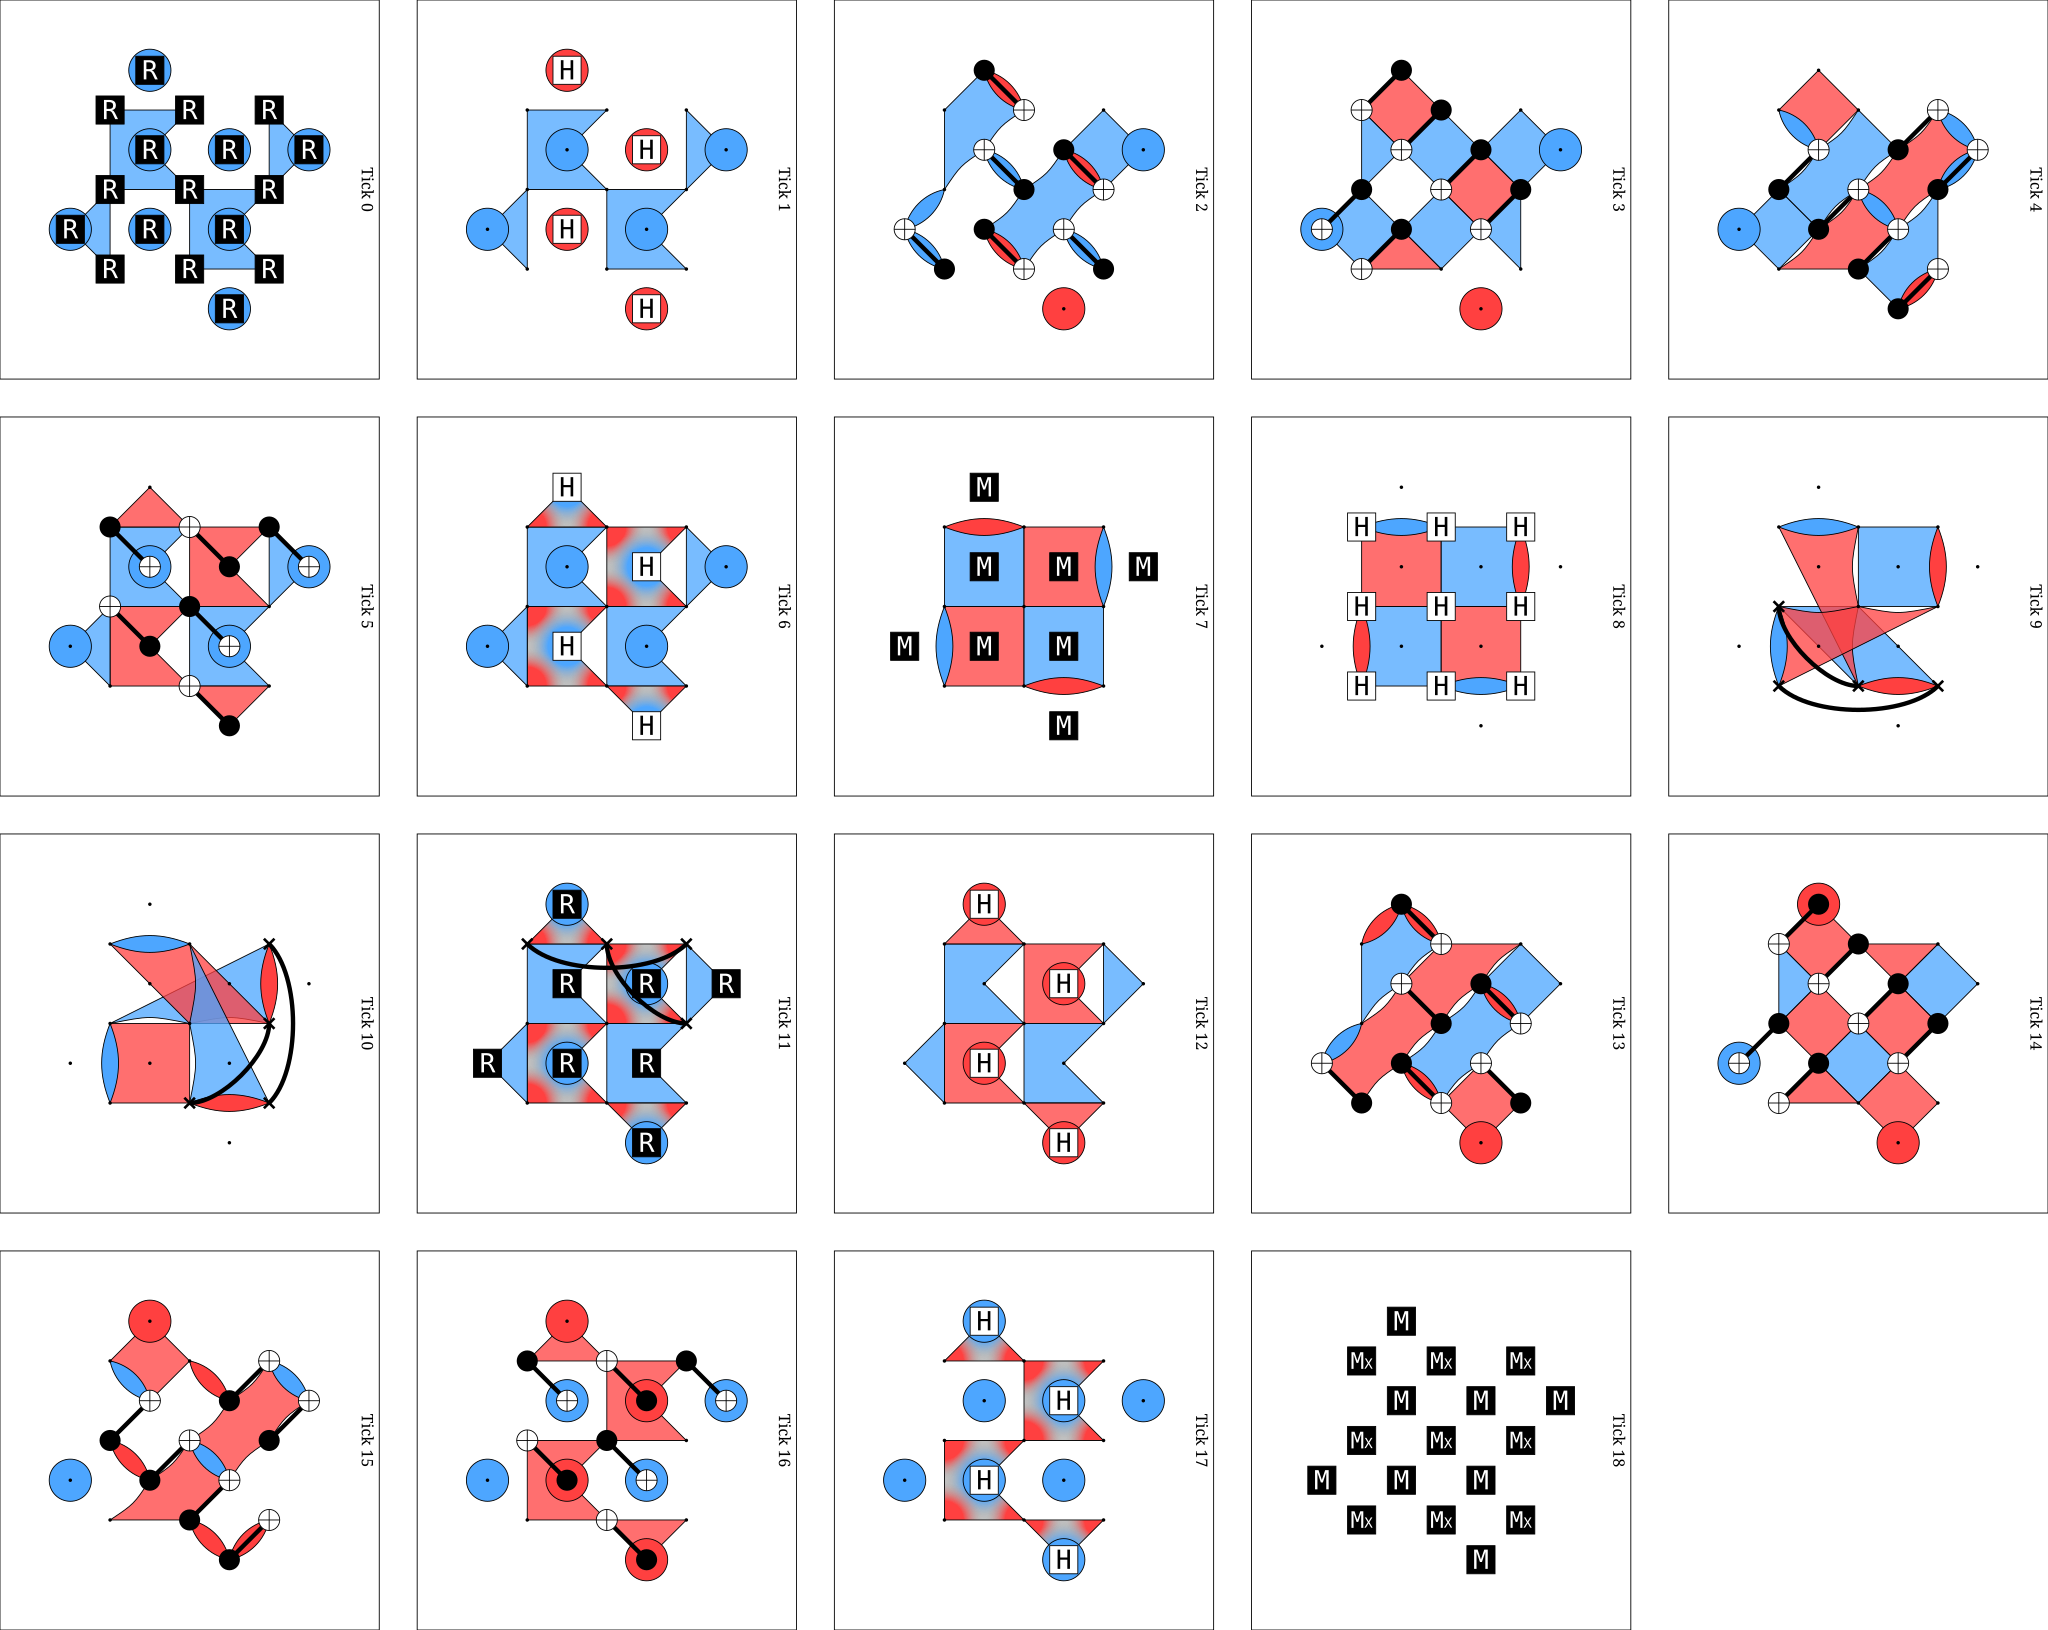

In [4]:
circuit_H_ZtoX.without_noise().diagram("detslice-with-ops-svg")

## 2. Noiseless Sanity Check

With no noise, every detector and observable must be deterministic (all zero) — a
direct check that $U_H$ preserves the code space and implements the intended logical
action.

In [5]:
for label, circ in [
    ("H Z->X", circuit_H_ZtoX),
    ("H X->Z", circuit_H_XtoZ),
]:
    sampler = circ.without_noise().compile_detector_sampler()
    det, obs = sampler.sample(shots=200, separate_observables=True)
    print(f"{label}: clean={not det.any() and not obs.any()}")

H Z->X: clean=True
H X->Z: clean=True


## 3. Simulation with MWPM (d=3, p=1e-3, 100k shots)

The transversal H uses only single-qubit $H$ and SWAP gates between data qubits — no
entangling CZ — so its detector error model stays **graphlike** and MWPM (PyMatching)
decodes it exactly. (The S gate's CZ layer is what forces BP+OSD in
`logical_H_S_unrotated.ipynb`.)

In [6]:
pipeline = SimulationPipeline(
    decoder_config=DecoderConfig("pymatching", backend="cpu"),
    max_shots=100_000,
    max_errors=50,
    num_workers=4,
    print_progress=False,
)

for label, circ in [
    ("H Z->X", circuit_H_ZtoX),
    ("H X->Z", circuit_H_XtoZ),
]:
    stats = pipeline.run(circ)
    print(f"{label}: LER={stats.logical_error_rate:.2e}  ({stats.errors} errors / {stats.shots:,} shots)")

H Z->X: LER=1.46e-03  (73 errors / 50,000 shots)


H X->Z: LER=1.68e-03  (84 errors / 50,000 shots)


## 4. Distance Suppression

A fault-tolerant logical gate must suppress the logical error rate as the code
distance grows. Comparing $d=3$ and $d=5$ at fixed $p=10^{-3}$ confirms the
transversal H is fault-tolerant: $\mathrm{LER}(d{=}5) \ll \mathrm{LER}(d{=}3)$.

In [7]:
for dd in (3, 5):
    noise = NoiseConfig(p_idle=p, p_1q=p, p_2q=p, p_meas=p, p_reset=p)
    with contextlib.redirect_stdout(io.StringIO()):
        c = build_gate_verification_circuit(
            dd, ["fold_transversal_hadamard"], init_basis="Z", measure_basis="X",
            rounds=rounds, unencode=False, noise_params=noise,
            code_patch_class=RotatedSurfaceCode,
            extraction_block_class=RotatedSurfaceCodeExtractionBlock,
        )
    stats = pipeline.run(c)
    print(f"rotated H  d={dd}  p={p}:  LER={stats.logical_error_rate:.2e}  "
          f"({stats.errors} errors / {stats.shots:,} shots)")

rotated H  d=3  p=0.001:  LER=1.70e-03  (85 errors / 50,000 shots)


rotated H  d=5  p=0.001:  LER=1.30e-04  (13 errors / 100,000 shots)


## 5. LER vs Physical Error Rate

Sweep the physical error rate `p ∈ {1e-3, 2e-3, 3e-3, 5e-3, 7e-3, 1e-2}` and plot the
**mean logical error rate over the two H sub-experiments** (Z→X, X→Z), one curve per
code distance. The transversal H is a single-time-slice logical gate, so a *constant*
`rounds = 1` already suffices — no `rounds = d` scaling — yet the spatial code distance
alone suppresses the LER below threshold (`LER(d=5) < LER(d=3)`), the two curves
crossing in the threshold region (`p ≈ 5e-3`–`1e-2`).

Decoding uses **MWPM (PyMatching)**: the transversal H has no entangling gate between
data qubits, so its detector error model is graphlike and MWPM decodes it exactly. Same
sweep settings (`P_SWEEP`, `DISTANCES`, plotting) as `logical_CNOT_LS_rotated.ipynb`.

  d         p   mean LER (over H Z->X, X->Z)
------------------------------------------------


  3     1e-03   1.490e-03


  3     2e-03   5.100e-03


  3     3e-03   8.050e-03


  3     5e-03   2.095e-02


...

  7     2e-03   2.150e-04


  7     3e-03   7.844e-04


  7     5e-03   4.596e-03


  7     7e-03   1.330e-02


  7     1e-02   4.234e-02


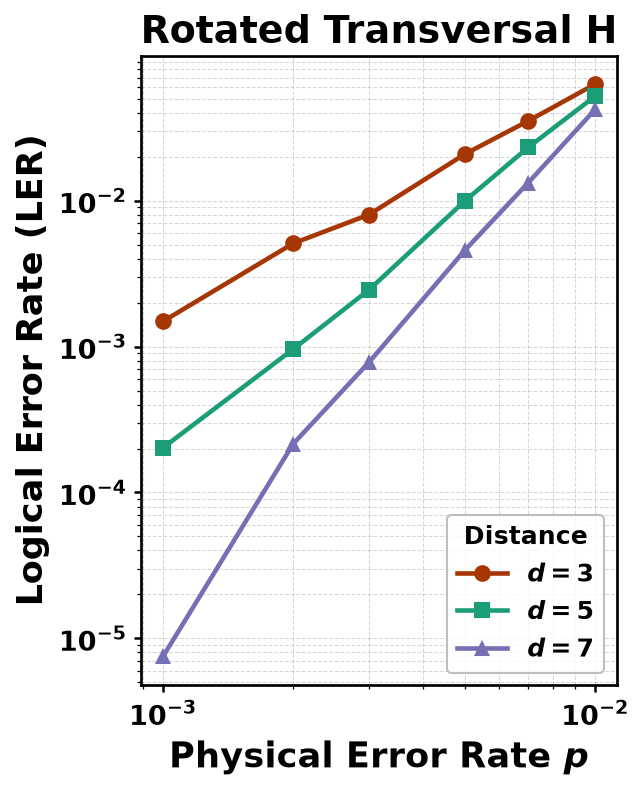

In [3]:
# ── LER vs Physical Error Rate ────────────────────────────────────────────────
import logging
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from lightstim.plot.styles import apply_paper_style, bold_ticks, PALETTE_DISTANCE
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)  # silence bold-font warnings

P_SWEEP   = [1e-3, 2e-3, 3e-3, 5e-3, 7e-3, 1e-2]
DISTANCES = [3, 5, 7]
MARKERS   = {3: "o", 5: "s", 7: "^"}

sweep_pipeline = SimulationPipeline(
    decoder_config=DecoderConfig("pymatching", backend="cpu"),
    max_shots=200_000,
    max_errors=60,
    num_workers=8,
    print_progress=False,
)

TITLE = "Rotated Transversal H"

ler_curves = {dd: [] for dd in DISTANCES}
print(f"{'d':>3} {'p':>9}   mean LER (over H Z->X, X->Z)")
print("-" * 48)
for dd in DISTANCES:
    for pp in P_SWEEP:
        noise = NoiseConfig(p_idle=pp, p_1q=pp, p_2q=pp, p_meas=pp, p_reset=pp)
        lers = []
        for ib, mb in [("Z", "X"), ("X", "Z")]:
            with contextlib.redirect_stdout(io.StringIO()):
                c = build_gate_verification_circuit(
                    dd, ["fold_transversal_hadamard"], init_basis=ib, measure_basis=mb,
                    rounds=rounds, unencode=False, noise_params=noise,
                    code_patch_class=RotatedSurfaceCode,
                    extraction_block_class=RotatedSurfaceCodeExtractionBlock)
            lers.append(sweep_pipeline.run(c).logical_error_rate)
        mean_ler = float(np.mean(lers))
        ler_curves[dd].append(mean_ler)
        print(f"{dd:>3} {pp:>9.0e}   {mean_ler:.3e}")

apply_paper_style()
fig, ax = plt.subplots(figsize=(4.5, 5.5))
proxies = []
for dd in DISTANCES:
    color  = PALETTE_DISTANCE.get(dd, "gray")
    marker = MARKERS.get(dd, "o")
    _y = np.array(ler_curves[dd], dtype=float)
    _y[_y <= 0] = np.nan  # drop zero-error points (e.g. d=7 low-p) from the log plot
    ax.loglog(P_SWEEP, _y, marker=marker, color=color,
              linestyle="-", markeredgecolor="none")
    proxies.append(mlines.Line2D([], [], color=color, ls="-", marker=marker,
                                 markersize=8, markeredgecolor="none", label=f"$d = {dd}$"))

ax.set_xlabel("Physical Error Rate $p$")
ax.set_ylabel("Logical Error Rate (LER)")
ax.set_title(TITLE)
ax.grid(True, which="both", ls="--", linewidth=0.5, alpha=0.5)
bold_ticks(ax)
leg = ax.legend(handles=proxies, title="Distance", loc="lower right",
                frameon=True, framealpha=0.85)
leg.get_title().set_fontweight("bold")
fig.tight_layout()
plt.show()